In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
import h5py
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [2]:
beta = 10.0

DATA_DIR = Path.cwd().parent.parent / "data" / "darcy_flow_data" 
FILE_PATH = DATA_DIR / "2D_DarcyFlow_beta10.0_Train.hdf5"

scale_factor = 1
NEW_FILE_PATH = DATA_DIR / f"2D_DarcyFlow_beta10.0_Train_Scale{scale_factor}.hdf5"

--- Numerical Sanity Checks (Sample 3) ---
Contains NaNs: False
Max absolute value on u boundaries: 8.075358e-01 (Should be ~0.0)


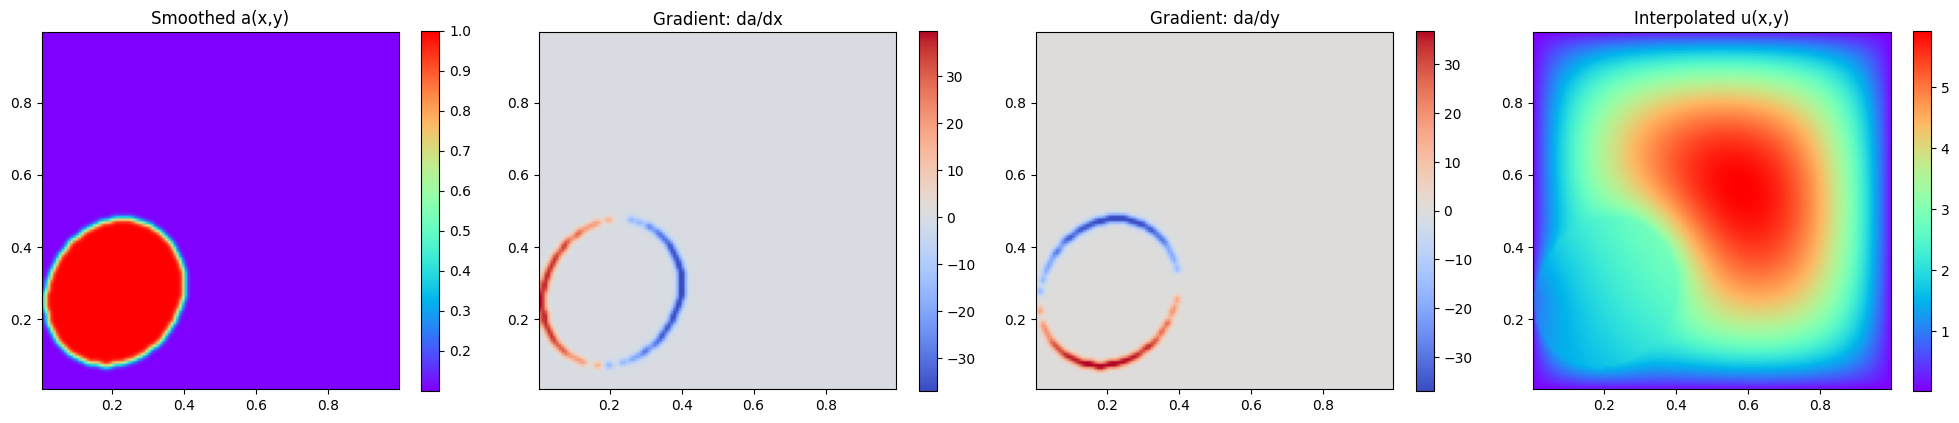

In [3]:
# Adjust path and scale_factor if needed
FILE_PATH = DATA_DIR / "2D_DarcyFlow_beta10.0_Train_Scale1.hdf5"

sample_idx = 3

with h5py.File(FILE_PATH, 'r') as f:
    # 1. Get grid dimensions
    fine_x = f['x-coordinate'][:]
    fine_y = f['y-coordinate'][:]
    fine_nx, fine_ny = len(fine_x), len(fine_y)
    
    # 2. Extract the sample and reshape back to 2D
    a_2d = f['a_flat'][sample_idx].reshape(fine_nx, fine_ny)
    ax_2d = f['a_x_flat'][sample_idx].reshape(fine_nx, fine_ny)
    ay_2d = f['a_y_flat'][sample_idx].reshape(fine_nx, fine_ny)
    u_2d = f['u_flat'][sample_idx].reshape(fine_nx, fine_ny)

# --- Numerical Checks ---
print(f"--- Numerical Sanity Checks (Sample {sample_idx}) ---")
print(f"Contains NaNs: {np.isnan(a_2d).any() or np.isnan(u_2d).any()}")

# Extract the boundary pixels of u
u_boundaries = np.concatenate([
    u_2d[0, :], u_2d[-1, :],  # Left and Right edges
    u_2d[:, 0], u_2d[:, -1]   # Bottom and Top edges
])
max_boundary_val = np.max(np.abs(u_boundaries))
print(f"Max absolute value on u boundaries: {max_boundary_val:.6e} (Should be ~0.0)")

# --- Visual Checks ---
# We transpose (.T) to match Cartesian plotting (x on horizontal, y on vertical)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
ext = [fine_x.min(), fine_x.max(), fine_y.min(), fine_y.max()]

im0 = axes[0].imshow(a_2d.T, origin='lower', cmap='rainbow', extent=ext)
axes[0].set_title("Smoothed a(x,y)")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ax_2d.T, origin='lower', cmap='coolwarm', extent=ext)
axes[1].set_title("Gradient: da/dx")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(ay_2d.T, origin='lower', cmap='coolwarm', extent=ext)
axes[2].set_title("Gradient: da/dy")
fig.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(u_2d.T, origin='lower', cmap='rainbow', extent=ext)
axes[3].set_title("Interpolated u(x,y)")
fig.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

In [4]:
print(f"Loading pre-processed dataset: {NEW_FILE_PATH.name}")

with h5py.File(NEW_FILE_PATH, 'r') as f:
    fine_x_coords = np.array(f['x-coordinate'][:])
    fine_y_coords = np.array(f['y-coordinate'][:])
    
    # Load the pre-calculated, pre-flattened arrays into memory
    all_a_flat = np.array(f['a_flat'][:])
    all_a_x_flat = np.array(f['a_x_flat'][:])
    all_a_y_flat = np.array(f['a_y_flat'][:])
    all_u_flat = np.array(f['u_flat'][:])

N_samples = all_a_flat.shape[0]
fine_nx, fine_ny = len(fine_x_coords), len(fine_y_coords)

# Coordinate generation
# Coordinate generation
x_l, x_u = float(np.min(fine_x_coords)), float(np.max(fine_x_coords)) 
y_l, y_u = float(np.min(fine_y_coords)), float(np.max(fine_y_coords)) 

X, Y = np.meshgrid(fine_x_coords, fine_y_coords, indexing='ij')
x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

# Because the HDF5 grid is cell-centered, ALL of these are strictly valid interior points
x_valid = x
y_valid = y
total_valid_points = x_valid.shape[0]

# --- Generate True Mathematical Boundaries ---
# The domain is defined mathematically as the unit square (0,1)^2
# Dynamically scale the boundary density to match the interior grid
edge_x = jnp.linspace(0.0, 1.0, fine_nx)
edge_y = jnp.linspace(0.0, 1.0, fine_ny)

# Bottom (y=0.0) and Top (y=1.0)
bc_bottom = jnp.stack([edge_x, jnp.zeros_like(edge_x)], axis=-1)
bc_top = jnp.stack([edge_x, jnp.ones_like(edge_x)], axis=-1)

# Left (x=0.0) and Right (x=1.0)
bc_left = jnp.stack([jnp.zeros_like(edge_y), edge_y], axis=-1)
bc_right = jnp.stack([jnp.ones_like(edge_y), edge_y], axis=-1)

# Combine all true boundary coordinates
all_bc_coords = jnp.concatenate([bc_bottom, bc_top, bc_left, bc_right], axis=0)
x_bc = all_bc_coords[:, 0].reshape(-1, 1)
y_bc = all_bc_coords[:, 1].reshape(-1, 1)

# Enforce exactly u=0.0 on these true boundaries
bc_val_array = jnp.zeros_like(x_bc)

Loading pre-processed dataset: 2D_DarcyFlow_beta10.0_Train_Scale1.hdf5


E0722 22:27:41.079724   96393 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0722 22:27:41.095798   96163 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [5]:
class DarcyFlowDataset(Dataset):
    def __init__(self, a_data, a_x_data, a_y_data, u_data):
        self.a = a_data
        self.a_x = a_x_data
        self.a_y = a_y_data
        self.u = u_data

    def __len__(self): return len(self.a)
    def __getitem__(self, idx): return self.a[idx], self.a_x[idx], self.a_y[idx], self.u[idx]

# n_train = int(N_samples * 0.9)
# n_val = int(N_samples * 0.05)

# train_dataset = DarcyFlowDataset(all_a_flat[:n_train], all_a_x_flat[:n_train], all_a_y_flat[:n_train], all_u_flat[:n_train])
# val_dataset = DarcyFlowDataset(all_a_flat[n_train:n_train+n_val], all_a_x_flat[n_train:n_train+n_val], all_a_y_flat[n_train:n_train+n_val], all_u_flat[n_train:n_train+n_val])
# test_dataset = DarcyFlowDataset(all_a_flat[n_train+n_val:], all_a_x_flat[n_train+n_val:], all_a_y_flat[n_train+n_val:], all_u_flat[n_train+n_val:])

# batch_size_samples = 8 
# train_dataloader = jd.DataLoader(train_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=True, drop_last=True)
# val_dataloader = jd.DataLoader(val_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=False)
# test_dataloader = jd.DataLoader(test_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=False)

n_train = 10
n_val = 5
n_test = 5
N_subset = n_train + n_val + n_test

# Slice sequentially to completely isolate the sets
train_dataset = DarcyFlowDataset(
    all_a_flat[:n_train], 
    all_a_x_flat[:n_train], 
    all_a_y_flat[:n_train], 
    all_u_flat[:n_train]
)

val_dataset = DarcyFlowDataset(
    all_a_flat[n_train : n_train + n_val], 
    all_a_x_flat[n_train : n_train + n_val], 
    all_a_y_flat[n_train : n_train + n_val], 
    all_u_flat[n_train : n_train + n_val]
)

test_dataset = DarcyFlowDataset(
    all_a_flat[n_train + n_val : N_subset], 
    all_a_x_flat[n_train + n_val : N_subset], 
    all_a_y_flat[n_train + n_val : N_subset], 
    all_u_flat[n_train + n_val : N_subset]
)

# Batch sizes
batch_size_samples = 10 
train_dataloader = jd.DataLoader(train_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=True, drop_last=True)
val_dataloader = jd.DataLoader(val_dataset, backend='pytorch', batch_size=n_val, shuffle=False)
test_dataloader = jd.DataLoader(test_dataset, backend='pytorch', batch_size=n_test, shuffle=False)

print(f"DataLoaders ready! (Train: {n_train}, Val: {n_val}, Test: {n_test})")

DataLoaders ready! (Train: 10, Val: 5, Test: 5)


In [6]:
epochs = 300
M = 1024
chunk_size = 256 
hidden_layers = [1024, 1024, 1024, 1024] 

total_features = hidden_layers[-1]
# sum(hidden_layers)

sigma = 1
tik_reg_fixed = 1e-5
matrix_bc_weight = 1e2
pde_loss_weight = 1.0
bc_loss_weight = 1e3
data_loss_weight = 0

rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2, M)) * sigma

# class FeatureExtractor(nn.Module):
#     hidden_layers: list
#     B_matrix: jnp.ndarray 
    
#     @nn.compact
#     def __call__(self, x_in, y_in):    

#         v = jnp.concatenate([x_in, y_in])

#         proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
#         h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])
#         all_features = []

#         h = h_rff
#         for size in self.hidden_layers:
#             h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
#             h = nn.tanh(h) 
#             all_features.append(h)
            
#         # Combine RFF and all MLP layers
#         combined_h = jnp.concatenate(all_features)
            
#         return combined_h

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
        return h 
    
model = FeatureExtractor(
    hidden_layers=hidden_layers, 
    B_matrix=B_matrix 
)

key = jax.random.PRNGKey(0)
dummy_x = jnp.array([0.0])
dummy_y = jnp.array([0.0])
params = model.init(key, dummy_x, dummy_y)

print(f"Calculated Total Features for V1: {total_features}")

Calculated Total Features for V1: 1024


In [7]:
def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_x = jacfwd(get_f, argnums=1)(params, x_val, y_val)
    f_y = jacfwd(get_f, argnums=2)(params, x_val, y_val)
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_x = jnp.squeeze(f_x, axis=-1)
    f_y = jnp.squeeze(f_y, axis=-1)
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    return f_x, f_y, f_xx, f_yy

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_x_chunk = jacfwd(get_f_chunk, argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_y_chunk = jacfwd(get_f_chunk, argnums=2)(params, x_val, y_val, start_idx, end_idx)
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    f_x_chunk = jnp.squeeze(f_x_chunk, axis=-1)
    f_y_chunk = jnp.squeeze(f_y_chunk, axis=-1)
    f_xx_chunk = jnp.squeeze(f_xx_chunk, axis=(-1, -2))
    f_yy_chunk = jnp.squeeze(f_yy_chunk, axis=(-1, -2))
    return f_x_chunk, f_y_chunk, f_xx_chunk, f_yy_chunk

def get_u_dir(params, x_val, y_val, w_current):
    f_x, f_y, f_xx, f_yy = get_f_dir(params, x_val, y_val)
    u_x = jnp.dot(f_x, w_current)
    u_y = jnp.dot(f_y, w_current)
    u_xx = jnp.dot(f_xx, w_current)
    u_yy = jnp.dot(f_yy, w_current)
    return u_x, u_y, u_xx, u_yy

f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

In [8]:
total_steps = epochs * len(train_dataloader)
lr_schedule = optax.cosine_decay_schedule(init_value=5e-4, decay_steps=total_steps, alpha=0.01)
optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)

# The vmap now ONLY handles the lightweight array multiplication
def multiply_coefficients(f_x, f_y, f_xx, f_yy, a_pde, a_x_pde, a_y_pde):
    return -(a_x_pde * f_x + a_y_pde * f_y + a_pde * (f_xx + f_yy))

batched_multiply = jax.vmap(multiply_coefficients, in_axes=(None, None, None, None, 0, 0, 0))

def get_A_and_b_optimized(params, x_pde, y_pde, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_chunks = []
    
    # 1. Compute Boundary Features (Runs ONCE)
    A_bc_full = []
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, end_idx) * jnp.sqrt(matrix_bc_weight)
        A_bc_full.append(A_bc_chunk)
    A_bc_matrix = jnp.hstack(A_bc_full)
    
    # 2. Iterate through chunks to assemble the full PDE matrix
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        
        # Runs ONCE per spatial chunk, regardless of batch size
        f_x, f_y, f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        
        # Broadcasts the scalar/array multiplication across the batch
        A_pde_batch = batched_multiply(f_x, f_y, f_xx, f_yy, a_batch, a_x_batch, a_y_batch)
        
        # Slice the pre-computed boundary matrix to match the current chunk's width
        A_bc_chunk_sliced = A_bc_matrix[:, start_idx:end_idx]
        
        # Stack PDE and BC for every sample in the batch
        A_bc_batched = jnp.repeat(A_bc_chunk_sliced[None, ...], a_batch.shape[0], axis=0)
        A_chunk_batched = jnp.concatenate([A_pde_batch, A_bc_batched], axis=1)
        
        A_chunks.append(A_chunk_batched)
        
    A_full_batch = jnp.concatenate(A_chunks, axis=-1)
    
    # 3. Assemble target vector b
    b_pde = jnp.ones_like(a_batch) * beta
    b_bc = bc_val_arr * jnp.sqrt(matrix_bc_weight)
    b_bc_batched = jnp.repeat(b_bc[None, ...], a_batch.shape[0], axis=0)
    b_full_batch = jnp.concatenate([b_pde, b_bc_batched], axis=1)
    
    return A_full_batch, b_full_batch

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_direct_solve_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_batch, b_batch = get_A_and_b_optimized(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    
    def solve_single(A, b):
        AtA = A.T @ A + tik_reg_fixed * jnp.eye(total_features)
        Atb = A.T @ b
        return jax.scipy.linalg.solve(AtA, Atb)
    
    return jax.vmap(solve_single)(A_batch, b_batch)

def compute_loss_single(params, w_current, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch):
    u_x, u_y, u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, w_current)
    laplacian_u = u_xx + u_yy
    
    pde_residual = -(a_x_batch * u_x + a_y_batch * u_y + a_batch * laplacian_u) - beta
    
    f_bc_vals = f_spatial_vmap(params, x_bc, y_bc)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    
    f_interior = f_spatial_vmap(params, x_batch, y_batch)
    u_pred_interior = jnp.dot(f_interior, w_current)
    
    loss_pde_unscaled = jnp.mean(pde_residual ** 2)
    loss_bc_unscaled = jnp.mean((u_bc_pred - bc_val_arr) ** 2)
    loss_data_unscaled = jnp.mean((u_pred_interior - u_batch) ** 2)
    
    loss_pde_scaled = loss_pde_unscaled * pde_loss_weight
    loss_bc_scaled = loss_bc_unscaled * bc_loss_weight
    loss_data_scaled = loss_data_unscaled * data_loss_weight
    
    return (loss_pde_scaled, loss_bc_scaled, loss_data_scaled), (loss_pde_unscaled, loss_bc_unscaled, loss_data_unscaled)

batched_compute_loss = jax.vmap(compute_loss_single, in_axes=(None, 0, None, None, 0, 0, 0, None, None, None, 0))

def full_forward_and_loss(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    w_batch = update_direct_solve_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    
    scaled_tup, unscaled_tup = batched_compute_loss(params, w_batch, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch)
    
    total_scaled = jnp.mean(scaled_tup[0]) + jnp.mean(scaled_tup[1]) + jnp.mean(scaled_tup[2])
    aux_unscaled = (jnp.mean(unscaled_tup[0]), jnp.mean(unscaled_tup[1]), jnp.mean(unscaled_tup[2]))
    
    return total_scaled, aux_unscaled

loss_grad_fn = jax.jit(value_and_grad(full_forward_and_loss, argnums=0, has_aux=True), static_argnames=['total_features', 'chunk_size'])

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    (loss_scaled, unscaled_tup), grads = loss_grad_fn(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss_scaled, unscaled_tup

@jax.jit
def fast_eval_step(params, w_batch, x_grid, y_grid, u_batch):
    f_eval = f_spatial_vmap(params, x_grid, y_grid)
    u_pred_batch = jnp.matmul(f_eval, w_batch)
    return jnp.mean((u_pred_batch - u_batch)**2)

def evaluate_dataset(dataloader, params, x_valid_grid, y_valid_grid, x_full, y_full):
    total_mse, total_samples = 0.0, 0
    rng = jax.random.PRNGKey(0)
    
    # FIX 4: Sample ONLY from valid interior points to build the collocation matrix
    val_spatial_idx = jax.random.choice(rng, jnp.arange(x_valid_grid.shape[0]), shape=(1000,), replace=False)
    test_x_chunk, test_y_chunk = x_valid_grid[val_spatial_idx], y_valid_grid[val_spatial_idx]
    
    for a_batch, a_x_batch, a_y_batch, u_batch in dataloader:
        w_val = update_direct_solve_batch(
            params, test_x_chunk, test_y_chunk, 
            a_batch[:, val_spatial_idx, :], a_x_batch[:, val_spatial_idx, :], a_y_batch[:, val_spatial_idx, :], 
            x_bc, y_bc, bc_val_array, total_features, chunk_size
        )
        
        # Evaluate MSE using the full grid (boundaries included)
        batch_mse = fast_eval_step(params, w_val, x_full, y_full, u_batch)
        total_mse += batch_mse.item() * a_batch.shape[0]
        total_samples += a_batch.shape[0]
        
    return total_mse / total_samples

In [ ]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0] 
spatial_batch_size = 5000 
total_bc_points = x_bc.shape[0]
bc_batch_size = 512

rng, pde_key, bc_key = jax.random.split(rng, 3)
spatial_indices = jax.random.permutation(pde_key, total_points)
bc_indices = jax.random.permutation(bc_key, total_bc_points)

ptr, bc_ptr = 0, 0 

history_total, history_pde, history_bc, history_data = [], [], [], []

for epoch in tqdm(range(epochs), desc="Training Epochs"):
    epoch_loss_scaled, ep_pde, ep_bc, ep_data, num_batches = 0.0, 0.0, 0.0, 0.0, 0
    
    for a_batch, a_x_batch, a_y_batch, u_batch in train_dataloader:
        
        if ptr + spatial_batch_size > total_points:
            rng, shuffle_key = jax.random.split(rng)
            spatial_indices = jax.random.permutation(shuffle_key, total_points)
            ptr = 0
            
        batch_idx = spatial_indices[ptr : ptr + spatial_batch_size]
        ptr += spatial_batch_size
        x_chunk, y_chunk = x[batch_idx], y[batch_idx]
        
        if bc_ptr + bc_batch_size > total_bc_points:
            rng, bc_shuffle_key = jax.random.split(rng)
            bc_indices = jax.random.permutation(bc_shuffle_key, total_bc_points)
            bc_ptr = 0
            
        bc_batch_idx = bc_indices[bc_ptr : bc_ptr + bc_batch_size]
        bc_ptr += bc_batch_size
        x_bc_chunk, y_bc_chunk = x_bc[bc_batch_idx], y_bc[bc_batch_idx]
        bc_val_chunk = bc_val_array[bc_batch_idx]
        
        params, opt_state, l_scaled, (l_pde, l_bc, l_data) = update_network(
            params, opt_state, x_chunk, y_chunk, 
            a_batch[:, batch_idx, :], a_x_batch[:, batch_idx, :], a_y_batch[:, batch_idx, :], 
            x_bc_chunk, y_bc_chunk, bc_val_chunk, u_batch[:, batch_idx, :], total_features, chunk_size
        )
        
        history_total.append(l_scaled)
        history_pde.append(l_pde)
        history_bc.append(l_bc)
        history_data.append(l_data)


        epoch_loss_scaled += l_scaled
        ep_pde += l_pde
        ep_bc += l_bc
        ep_data += l_data
        num_batches += 1


    # --- AFTER the entire training loop is finished ---
    # Convert the entire list of JAX arrays to a single numpy array (or list of floats) all at once
    history_total = np.array(history_total).tolist()
    history_pde = np.array(history_pde).tolist()
    history_bc = np.array(history_bc).tolist()
    history_data = np.array(history_data).tolist()

    # history_total.append(float(epoch_loss_scaled / num_batches))
    # history_pde.append(float(ep_pde / num_batches))
    # history_bc.append(float(ep_bc / num_batches))
    # history_data.append(float(ep_data / num_batches))
    
    val_mse = evaluate_dataset(val_dataloader, params, x_valid, y_valid, x, y)
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {history_total[-1]:.4e} | Val MSE: {val_mse:.4e} | PDE(un): {history_pde[-1]:.3e} | BC(un): {history_bc[-1]:.3e}")

Training Epochs:   0%|          | 0/300 [00:00<?, ?it/s]

E0722 22:27:53.510248   96411 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Epoch 001 | Train Loss: 2.4158e+02 | Val MSE: 8.6860e-01 | PDE(un): 1.919e+01 | BC(un): 2.224e-01
Epoch 011 | Train Loss: 1.2561e+02 | Val MSE: 1.4579e+00 | PDE(un): 2.986e+01 | BC(un): 9.574e-02
Epoch 021 | Train Loss: 5.8635e+01 | Val MSE: 1.1019e+00 | PDE(un): 3.276e+01 | BC(un): 2.587e-02
Epoch 031 | Train Loss: 4.7780e+01 | Val MSE: 1.1684e+00 | PDE(un): 3.135e+01 | BC(un): 1.643e-02
Epoch 041 | Train Loss: 4.3688e+01 | Val MSE: 1.0532e+00 | PDE(un): 2.979e+01 | BC(un): 1.390e-02
Epoch 051 | Train Loss: 3.9757e+01 | Val MSE: 1.0412e+00 | PDE(un): 2.862e+01 | BC(un): 1.114e-02
Epoch 061 | Train Loss: 3.7643e+01 | Val MSE: 6.2346e-01 | PDE(un): 2.764e+01 | BC(un): 1.000e-02
Epoch 071 | Train Loss: 3.5333e+01 | Val MSE: 1.0769e+00 | PDE(un): 2.567e+01 | BC(un): 9.662e-03
Epoch 081 | Train Loss: 3.4604e+01 | Val MSE: 5.5197e-01 | PDE(un): 2.583e+01 | BC(un): 8.777e-03
Epoch 091 | Train Loss: 3.0125e+01 | Val MSE: 1.1412e+00 | PDE(un): 2.303e+01 | BC(un): 7.095e-03
Epoch 101 | Train Lo

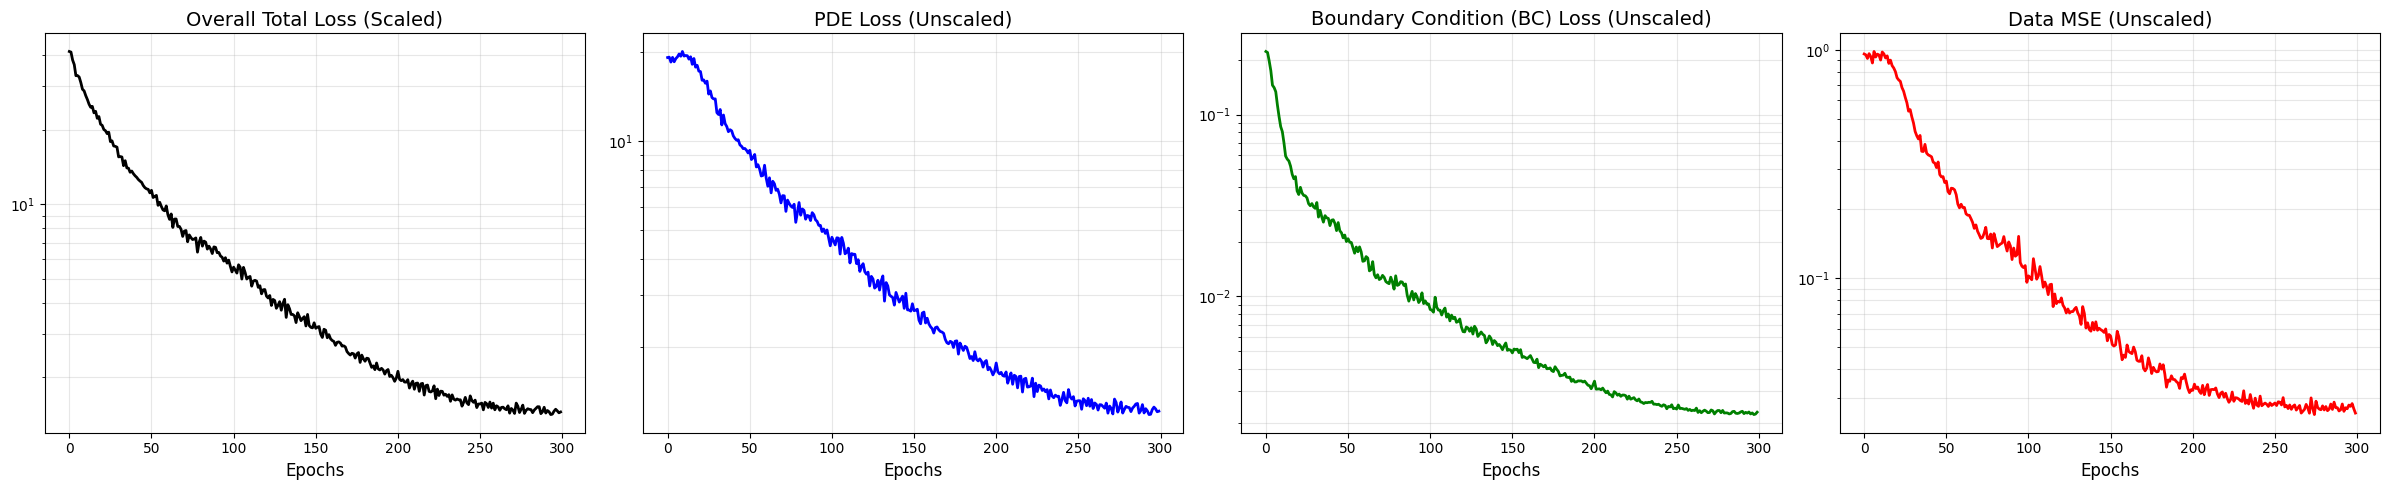

In [ ]:
# --- Plot Losses ---
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

axes[0].plot(history_total, color='black', linewidth=2)
axes[0].set_title('Overall Total Loss (Scaled)', fontsize=14)
axes[1].plot(history_pde, color='blue', linewidth=2)
axes[1].set_title('PDE Loss (Unscaled)', fontsize=14)
axes[2].plot(history_bc, color='green', linewidth=2)
axes[2].set_title('Boundary Condition (BC) Loss (Unscaled)', fontsize=14)
axes[3].plot(history_data, color='red', linewidth=2)
axes[3].set_title('Data MSE (Unscaled)', fontsize=14)

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('Epochs', fontsize=12)
    ax.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()

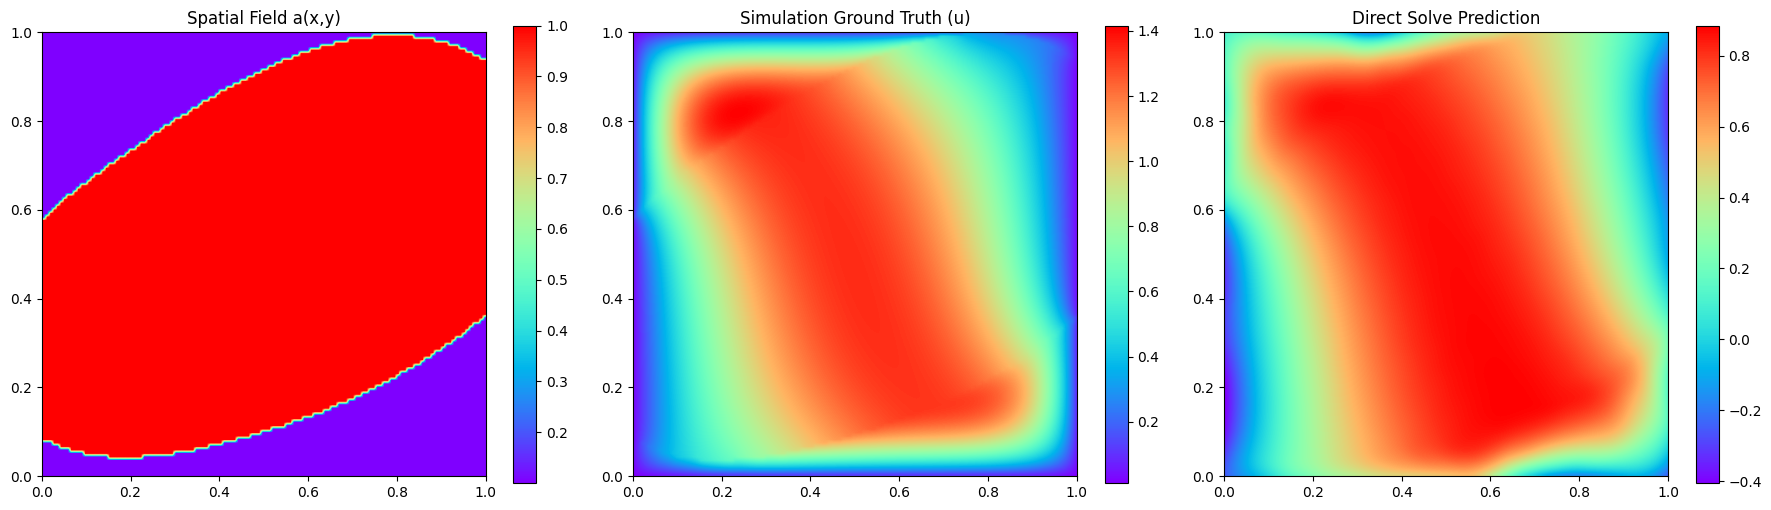

In [ ]:
# --- Predict & Evaluate on Test Sample ---
test_idx = 0
a_sample, a_x_sample, a_y_sample, u_sim_sample = test_dataset[test_idx]

# Expand dims to act as a batch of 1
a_batch = a_sample[None, ...]  
a_x_batch = a_x_sample[None, ...]
a_y_batch = a_y_sample[None, ...]

# Because x and y only contain interior points, sample directly from the entire array
rng_plot = jax.random.PRNGKey(1)
plot_spatial_idx = jax.random.choice(rng_plot, jnp.arange(x.shape[0]), shape=(15000,), replace=False)

# Solve for w using the fine-grid features and parameters
w_plot = update_direct_solve_batch(
    params, x, y, 
    a_batch, a_x_batch, a_y_batch, 
    x_bc, y_bc, bc_val_array, total_features, chunk_size
)

# Load original raw data for plotting directly from the original HDF5
ORIGINAL_FILE_PATH = DATA_DIR / "2D_DarcyFlow_beta10.0_Train.hdf5"
global_test_idx = n_train + n_val + test_idx

with h5py.File(ORIGINAL_FILE_PATH, 'r') as f_orig:
    x_coords = np.array(f_orig['x-coordinate'][:])
    y_coords = np.array(f_orig['y-coordinate'][:])
    raw_a_sim = np.array(f_orig['nu'][global_test_idx])
    raw_u_sim = np.array(f_orig['tensor'][global_test_idx]).squeeze()

nx, ny = len(x_coords), len(y_coords)

# Create the original low-res coordinate grid
X_orig, Y_orig = np.meshgrid(x_coords, y_coords, indexing='ij')
x_orig = jnp.array(X_orig.reshape(-1, 1))
y_orig = jnp.array(Y_orig.reshape(-1, 1))

# Predict directly on the original coordinate grid
f_orig = f_spatial_vmap(params, x_orig, y_orig)
u_pred_orig = jnp.dot(f_orig, w_plot[0])

# --- Dynamic Plotting ---
a_plot = raw_a_sim.T
u_sim_plot = raw_u_sim.T 
u_pred_plot = u_pred_orig.reshape(nx, ny).T

vmin_true = float(jnp.min(u_sim_plot))
vmax_true = float(jnp.max(u_sim_plot))

# Hardcode the true mathematical domain limits
ext = [0.0, 1.0, 0.0, 1.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y)')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Direct Solve Prediction')

plt.tight_layout()
plt.show()

In [ ]:
# --- Relative L2 Error ---
error_l2_norm = jnp.linalg.norm(u_pred_orig.flatten() - raw_u_sim.flatten())
true_l2_norm = jnp.linalg.norm(raw_u_sim.flatten())
relative_l2 = error_l2_norm / true_l2_norm
print(f"Relative L2 Error: {relative_l2:.4e} (or {relative_l2 * 100:.2f}%)")

Relative L2 Error: 3.8174e-01 (or 38.17%)
